In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\human\Desktop\DAy 6\student_performance.csv")

# Create Target Column

In [4]:
df["Pass"] = (df["Final_Score"] >= 60).astype(int)

# Features and Target

In [5]:
X = df[["Attendance", "Assignment_Score", "Midterm_Score", "Final_Score"]]
y = df["Pass"]

# Train-Test Split

In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Logistic Regression

In [7]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

# Decision Tree

In [8]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

# Evaluation Function

In [9]:
def evaluate_model(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0)
    ]

lr_results = evaluate_model(y_test, lr_pred)
dt_results = evaluate_model(y_test, dt_pred)

# Comparison Table

In [10]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [lr_results[0], dt_results[0]],
    "Precision": [lr_results[1], dt_results[1]],
    "Recall": [lr_results[2], dt_results[2]],
    "F1 Score": [lr_results[3], dt_results[3]]
})

print(comparison)

print("\nLogistic Regression Confusion Matrix")
print(confusion_matrix(y_test, lr_pred))

print("\nDecision Tree Confusion Matrix")
print(confusion_matrix(y_test, dt_pred))

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression       1.0        1.0     1.0       1.0
1        Decision Tree       1.0        1.0     1.0       1.0

Logistic Regression Confusion Matrix
[[6]]

Decision Tree Confusion Matrix
[[6]]


c:\Users\human\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\human\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


# Visualization 1 – Model Accuracy Comparison

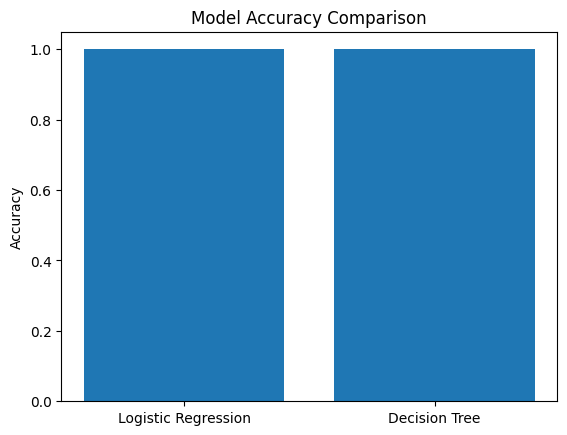

In [11]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree"]
accuracy = [lr_results[0], dt_results[0]]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# Visualization 2 – Pass vs Fail Distribution

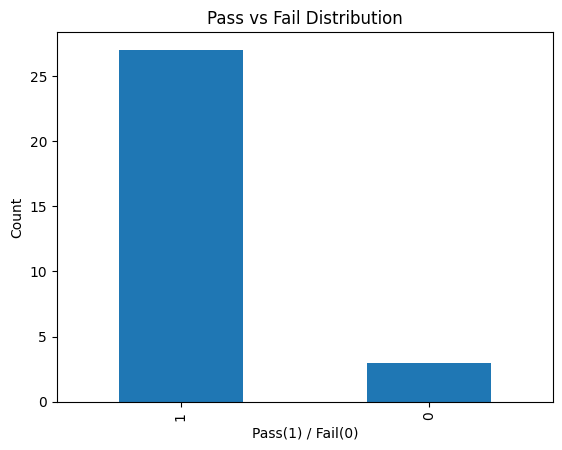

In [12]:
df["Pass"].value_counts().plot(kind="bar")
plt.title("Pass vs Fail Distribution")
plt.xlabel("Pass(1) / Fail(0)")
plt.ylabel("Count")
plt.show()